In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lp_analysis import load_and_preprocess
from lp_analysis_multi_pool import clamp_dfs
from scipy.stats.mstats import winsorize
from sklearn.cluster import KMeans
from scipy.stats.mstats import winsorize
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler

pd.options.plotting.backend = "plotly"
pd.options.display.max_columns=100
pd.options.display.max_rows = 50

stem = 'wbtc_weth' # to identify a particular token pair

low_events = load_and_preprocess(f"data/{stem}_500.csv", n_rows=None) # raw events data
high_events = load_and_preprocess(f"data/{stem}_3000.csv", n_rows=None)

low_events['fee_tier'] = 'low_fee'
high_events['fee_tier'] = 'high_fee'

dfs = clamp_dfs([low_events,high_events])

low_events = dfs[0]
high_events = dfs[1]

high_fee = pd.read_parquet(f'data/lp_analysis_output_{stem}_3000.parquet') # analyzed / processed data
low_fee = pd.read_parquet(f"data/lp_analysis_output_{stem}_500.parquet")
# concat analyses to do analysis across pools

low_fee['fee_tier'] = 'low_fee'
high_fee['fee_tier'] = 'high_fee'

df = pd.concat([low_fee,high_fee],axis=0)


Loading data/wbtc_weth_500.csv...


/Users/ashertobinchodos/Documents/uniswappy_thrack/simulation/lp_analysis.py:29: DtypeWarning: Columns (8,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, usecols=required_columns)


Loading data/wbtc_weth_3000.csv...


/Users/ashertobinchodos/Documents/uniswappy_thrack/simulation/lp_analysis.py:29: DtypeWarning: Columns (7,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, usecols=required_columns)


# Overview looks to compare trader / LP behaviors across pools.

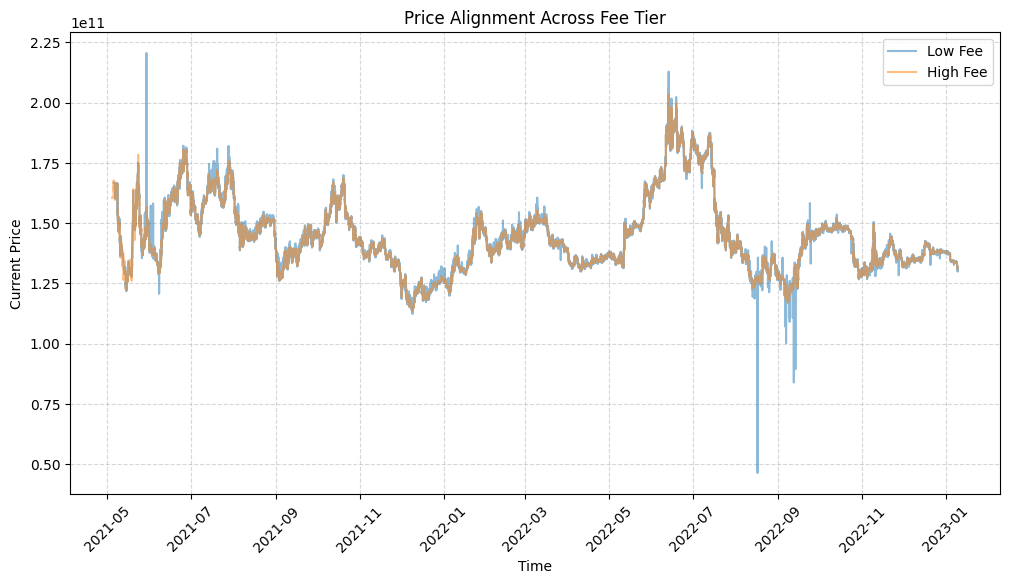

In [3]:
plt.figure(figsize=(12,6))
plt.plot(
    low_events.set_index('evt_block_time').current_price,
    alpha=0.5,
    label="Low Fee"
)
plt.plot(
    high_events.set_index('evt_block_time').current_price,
    alpha=0.5,
    label="High Fee"
)

plt.title("Price Alignment Across Fee Tier")
plt.xlabel("Time")
plt.ylabel("Current Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

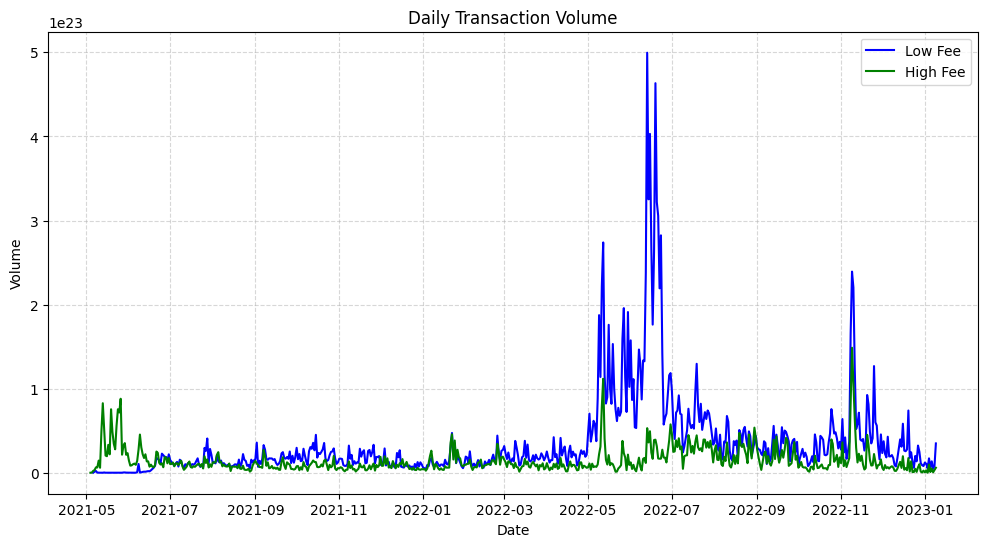

In [4]:
low_daily = (
    low_events
    .groupby(low_events[low_events.event == 'swap']['evt_block_time'].dt.date)['amount1']
    .apply(lambda x: x.abs().sum())
)
high_daily = (
    high_events
    .groupby(high_events[high_events.event == 'swap']['evt_block_time'].dt.date)['amount1']
    .apply(lambda x: x.abs().sum())
)
low_daily.index = pd.to_datetime(low_daily.index)
high_daily.index = pd.to_datetime(high_daily.index)

# Plot
plt.figure(figsize=(12,6))
plt.plot(low_daily.index, low_daily, label="Low Fee", color="blue")
plt.plot(high_daily.index, high_daily, label="High Fee", color="green")
plt.title("Daily Transaction Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [5]:
for df_ in [low_events,high_events]:
    df_['liquidity_valuation'] = np.where(df_.event != 'swap',
                                     df_.amount0 * df_.current_price + df_.amount1,
                                     0)
for _df in [low_events, high_events]:
    _df["liquidity"] = _df.loc[
        _df.event.isin(["mint", "burn"]), "liquidity_valuation"
    ].cumsum()

edf = pd.concat([low_events,high_events],axis=0)
edf["date"] = edf.evt_block_time.dt.date
edf.groupby(["fee_tier", "date"])[["liquidity"]].mean().clip(
    upper=10**30
).reset_index("fee_tier").plot(y="liquidity", color="fee_tier", title = 'Cumulative Liquidity Inflows (Daily Average)')

# Cluster LPs


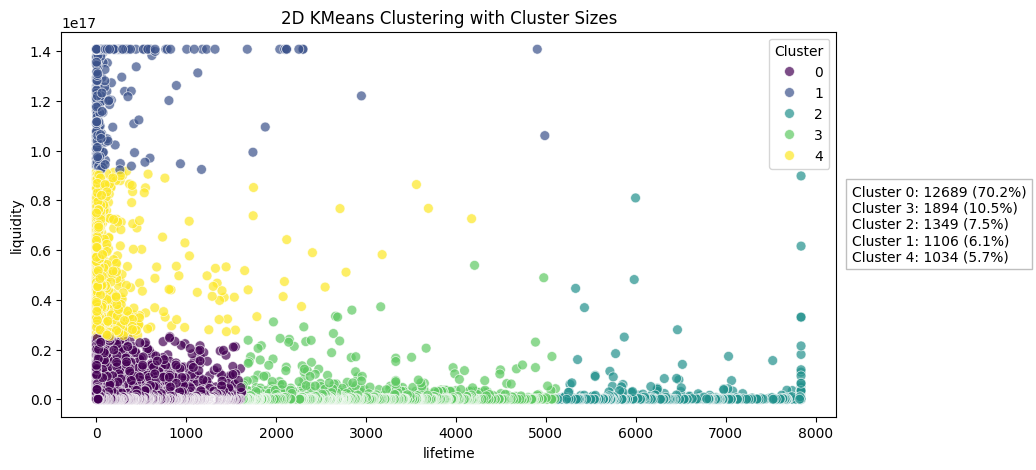

In [6]:


df['liq_w'] = winsorize(df.avg_liq, limits=[0.05, 0.05])
df['lifetime_w'] = winsorize(df.lifetime_hours, limits=[0.05, 0.05])

df["avg_liq*lifetime"] = df.liq_w * df.lifetime_w
df["avg_liq*lifetime_hours"] = winsorize(df["avg_liq*lifetime"], limits=[0.05, 0.05])

X = df[['liq_w','lifetime_w']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10,5))
sns.scatterplot(
    x=df['lifetime_w'],
    y=df["liq_w"],
    hue=df["cluster"],
    palette="viridis",
    s=50,
    alpha=0.7
)

cluster_counts = df['cluster'].value_counts()
total = len(df)
textstr = '\n'.join([f"Cluster {c}: {count} ({count/total*100:.1f}%)" 
                     for c, count in cluster_counts.items()])

plt.xlabel("lifetime")
plt.ylabel("liquidity")
plt.title("2D KMeans Clustering with Cluster Sizes")
plt.gca().text(1.02, 0.5, textstr, transform=plt.gca().transAxes,
               fontsize=10, verticalalignment='center',
               bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

plt.legend(title="Cluster")

plt.show()

# consistent cluster color mapping
cluster_colors = {0: "#440154", 1: "#31688e", 2: "#35b779", 3: "#fde725", 4: "#f4777f"}


# Get LP Staking Rewards per Cluster

In [7]:
df['in_range'] = df.avg_liq * df.in_range
rewards_cols = ['total_fee_CM2M','volume','in_range']

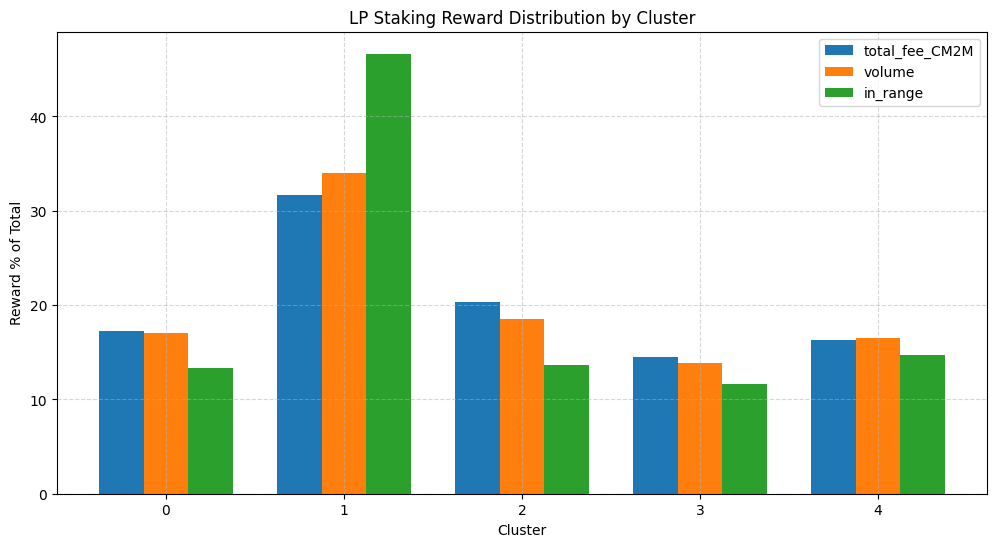

In [8]:



# Convert each reward to percent of its total
df_pct = df.copy()
for col in rewards_cols:
    df_pct[col] = df[col] / df[col].sum() * 100

# Aggregate by cluster (sum or mean, here we use sum)
cluster_rewards = df_pct.groupby('cluster')[rewards_cols].sum().reset_index()

# Plot grouped bar chart
x = np.arange(len(cluster_rewards['cluster']))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - width, cluster_rewards['total_fee_CM2M'], width, label='total_fee_CM2M')
plt.bar(x, cluster_rewards['volume'], width, label='volume')
plt.bar(x + width, cluster_rewards['in_range'], width, label='in_range')

plt.xlabel("Cluster")
plt.ylabel("Reward % of Total")
plt.title("LP Staking Reward Distribution by Cluster")
plt.xticks(x, cluster_rewards['cluster'])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## Note that fee and volume are linearly related by fee tier.

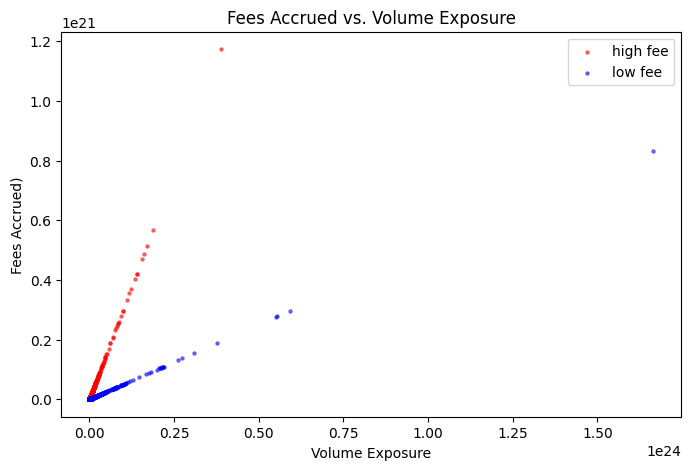

In [9]:


plt.figure(figsize=(8,5))

df_high = df[df.fee_tier == 'high_fee']
plt.scatter(df_high["volume"], df_high["total_fee_CM2M"], color="red", alpha=0.5, label="high fee", s = 5)

df_low = df[df.fee_tier == 'low_fee']
plt.scatter(df_low["volume"], df_low["total_fee_CM2M"], color="blue", alpha=0.5, label="low fee", s = 5)

plt.xlabel("Volume Exposure")
plt.ylabel("Fees Accrued)")
plt.title("Fees Accrued vs. Volume Exposure")
plt.legend()
plt.show()

Note the appearance of IL with both positive and negative price appreciation.

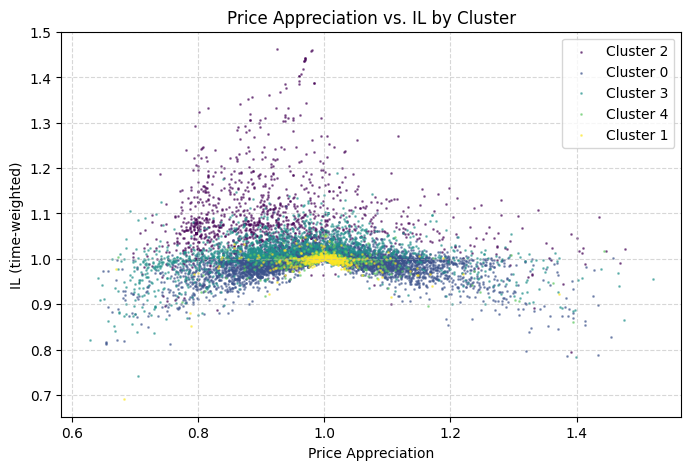

In [10]:

cluster_colors = {c: color for c, color in zip(df['cluster'].unique(), plt.cm.viridis(np.linspace(0, 1, df['cluster'].nunique())))}

plt.figure(figsize=(8,5))

for c, color in cluster_colors.items():
    df_c = df[df['cluster'] == c]
    plt.scatter(df_c["price_apprec"], df_c["il_time_weighted"], color=color, alpha=0.5, s=1, label=f"Cluster {c}")

plt.xlabel("Price Appreciation")
plt.ylabel("IL (time-weighted)")
plt.title("Price Appreciation vs. IL by Cluster")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## Note the ability of fees to (sometimes) effectively mitigate IL.

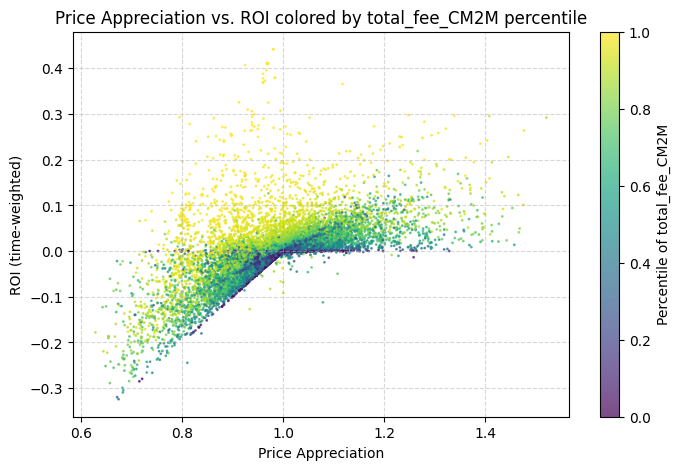

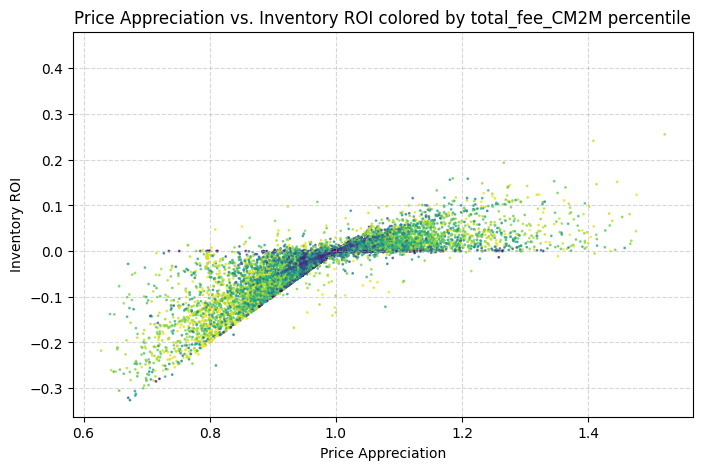

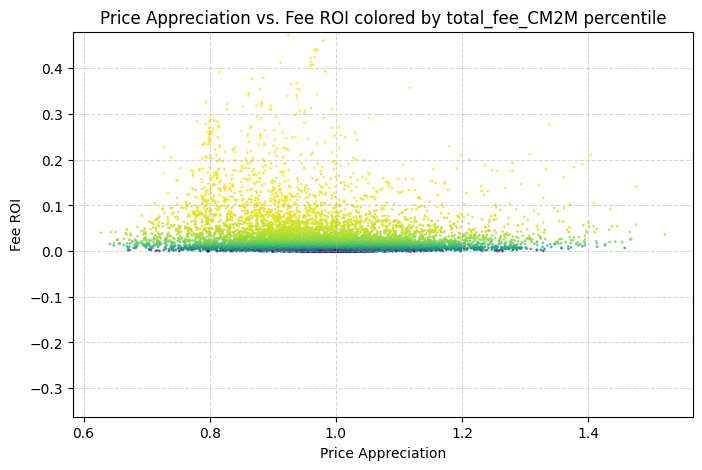

In [11]:


colors = plt.cm.viridis(df["fee_roi"].rank(pct=True))

plt.figure(figsize=(8,5))
plt.scatter(df["price_apprec"], df["roi_time_weighted"], c=colors, s=1, alpha=0.7)
plt.xlabel("Price Appreciation")
plt.ylabel("ROI (time-weighted)")
plt.title("Price Appreciation vs. ROI colored by total_fee_CM2M percentile")
plt.grid(True, linestyle="--", alpha=0.5)
cbar = plt.colorbar()
cbar.set_label("Percentile of total_fee_CM2M")
ylim = plt.gca().get_ylim()
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(df["price_apprec"], df["inv_roi"], c=colors, s=1, alpha=0.7)
plt.xlabel("Price Appreciation")
plt.ylabel("Inventory ROI")
plt.title("Price Appreciation vs. Inventory ROI colored by total_fee_CM2M percentile")
plt.grid(True, linestyle="--", alpha=0.5)
plt.ylim(ylim[0],ylim[1])
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df["price_apprec"], 1 + df["fee_roi"], c=colors, s=1, alpha=0.7)
plt.xlabel("Price Appreciation")
plt.ylabel("Fee ROI")
plt.title("Price Appreciation vs. Fee ROI colored by total_fee_CM2M percentile")
plt.grid(True, linestyle="--", alpha=0.5)
plt.ylim(ylim)
plt.show()


Note the importance of price appreciation as a driver of LP P/L.

In [12]:
numeric_cols = df._get_numeric_data().columns 
c = df[numeric_cols].corr()
c['roi_time_weighted'].sort_values(ascending=False)[:6].plot(
    title  = 'Ranked ROI Correlations'
    
)

